# M2A1 - Detecção e Extração de Características

Na prática de hoje vamos utilizar [OpenCV](https://opencv.org/) para extrair características de imagens.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Extração de Caracteísticas
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [7]:
!pip install opencv-python

Importar as bibliotecas e Ler Imagens do Disco

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [9]:
# TODO Atualize o path da imagem.
image = cv2.imread("1.jpeg")

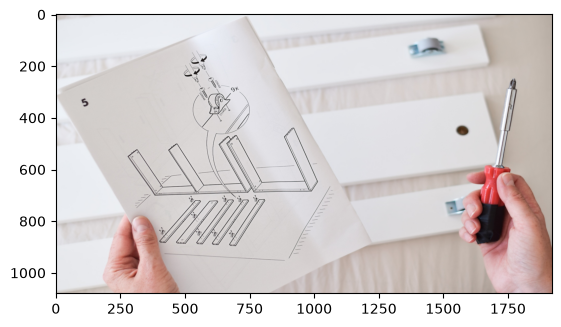

In [10]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Extração de Caracteísticas

Agora podemos criar o extrator e aplicar ele. Por exemplo o [SIFT](https://www.cs.ubc.ca/~lsigal/425_2024W1/ijcv04.pdf).

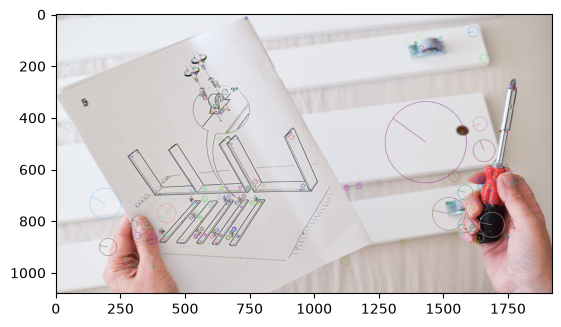

In [11]:
# Criando o detector do SIFT.
sift = cv2.SIFT_create()

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = sift.detectAndCompute(image, None)

# Visualizando os ketypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))

OpenCV também implementa outros detectores como o [ORB](https://par.cse.nsysu.edu.tw/resource/paper/2016/161129/ORB-an%20efficient%20alternative%20to%20SIFT%20or%20SURF.pdf).

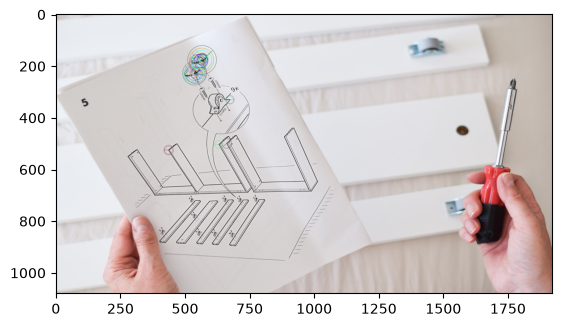

In [12]:
# Criando o detector do ORB.
orb = cv2.ORB_create(30)

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = orb.detectAndCompute(image, None)

# Visualizando os keypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))

E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremos utilizar essas características para encontrar correspondências em imagens.

Uma lista não exaustiva de referências segue:

- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Leia a imagem e rode todos os comandos.
- [ ] Existe alguma forma de melhorar os resutlados do SIFT?
- [ ] Existem outros detectores já implementados pela OpenCV?

In [20]:
image = cv2.imread("1.jpeg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [ ]:
# Criando o detector do SIFT.
sift = cv2.SIFT_create()

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = sift.detectAndCompute(image, None)

# Visualizando os ketypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))


# Criando o detector do ORB.
orb = cv2.ORB_create(30)

# Detectando os keypoints e calculando os descritores.
keypoints, descriptors = orb.detectAndCompute(image, None)

# Visualizando os keypoints.
image_kp = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_kp, cv2.COLOR_BGR2RGB))

[X] Existe alguma forma de melhorar os resutlados do SIFT?

Aumentando o contraste com CLAHE, ajustando parâmetros do SIFT

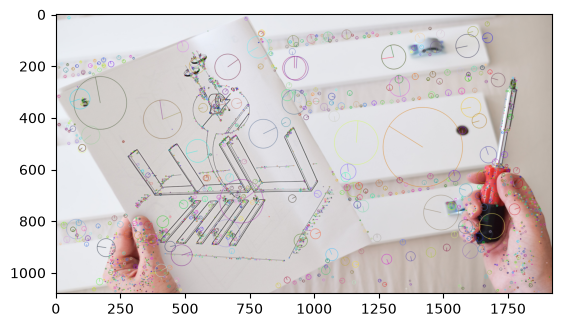

In [ ]:


# 1. contraste local
clahe = cv2.createCLAHE(2.0, (8,8))
gray = clahe.apply(gray)

# 2. redução de ruído antes do SIFT
gray = cv2.GaussianBlur(gray, (3,3), 0)

# 3. SIFT ajustado
sift = cv2.SIFT_create(
    contrastThreshold=0.02,
    edgeThreshold=10
)

keypoints, descriptors = sift.detectAndCompute(gray, None)

img_kp = cv2.drawKeypoints(
    image,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.show()

- [X] Existem outros detectores já implementados pela OpenCV?

Aplicando SIFT, ORB e AKAZE na mesma imagem e desenhar os keypoints

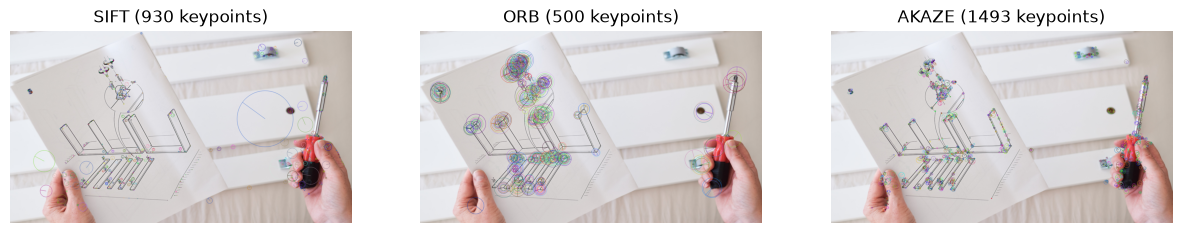

In [14]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

detectors = {
    "SIFT": cv2.SIFT_create(),
    "ORB": cv2.ORB_create(),
    "AKAZE": cv2.AKAZE_create()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, detector) in zip(axes, detectors.items()):
    kp, des = detector.detectAndCompute(gray, None)
    img_kp = cv2.drawKeypoints(
        image, kp, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    ax.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} ({len(kp)} keypoints)")
    ax.axis("off")

plt.show()